# Lab 2: Decision Tree & Random Forest (Beginner Guide)

**Goal:** By the end of this lab, you will understand:
- How a **Decision Tree** makes predictions by asking a series of Yes/No questions
- How a **Random Forest** combines MANY decision trees to make better predictions
- How to train, test, and evaluate both models using **scikit-learn (sklearn)**

**Dataset for this lab:** The famous **Titanic Dataset** — we will predict whether a passenger **survived** or **not**, based on details like their ticket class, age, sex, and fare paid.

**CSV link (you can open this in a browser or use it directly in code, no download needed):**
`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


## Step 0: Import the libraries we need

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("All libraries loaded successfully!")


All libraries loaded successfully!


## What is a Decision Tree? (Simple words)

Imagine you're trying to guess if a Titanic passenger survived, and you can only ask Yes/No questions, one at a time:

1. "Was the passenger travelling in 1st class?" → if Yes, more likely to survive
2. "Is the passenger female?" → if Yes, more likely to survive
3. "Is the passenger a child?" → if Yes, more likely to survive

A Decision Tree literally builds this **flowchart of questions** automatically from the data. Each question is a "split", and at the bottom of the tree are the final answers (leaves): **Survived** or **Did not survive**.

**Pros:** Easy to understand, you can literally draw the tree and explain it.
**Cons:** A single tree can "memorize" the training data too much (this is called **overfitting**) and may not generalize well to new passengers.

## What is a Random Forest? (Simple words)

A Random Forest is simply **many Decision Trees working as a team**.

- Each tree in the forest is trained on a slightly different random sample of the data and features.
- To make a final prediction, every tree "votes" (Survived or Not Survived), and the **majority vote wins**.

Think of it like asking 100 different doctors for a diagnosis instead of just 1 — even if a few of them are wrong, the majority is usually right. This makes Random Forest more accurate and more stable than a single Decision Tree.


## Step 1: Load the Titanic dataset

We'll load it straight from the internet using `pandas.read_csv()`.


In [40]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
print("Shape (rows, columns):", titanic_df.shape)
print()
titanic_df.info()


Shape (rows, columns): (891, 12)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


### Understanding the columns

| Column | Meaning |
|---|---|
| `Survived` | 1 = survived, 0 = did not survive (this is what we want to predict) |
| `Pclass` | Ticket class: 1 = 1st class, 2 = 2nd class, 3 = 3rd class |
| `Sex` | male / female |
| `Age` | Age in years (some values are missing) |
| `SibSp` | Number of siblings/spouses aboard |
| `Parch` | Number of parents/children aboard |
| `Fare` | Ticket price |
| `Embarked` | Port they boarded from |

We will drop columns like `Name`, `Ticket`, `Cabin`, and `PassengerId` because they are either free text or mostly missing, and not useful for a beginner model.


In [42]:
# Step 2: Keep only useful columns
columns_to_use = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
titanic_df = titanic_df[columns_to_use]

# Check how many missing values each column has
titanic_df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

### Step 3: Handle missing values (simple words)

Machine learning models cannot handle empty/missing cells. So we fill them in:
- `Age` has some missing values → we fill them with the **median age** (the middle value, a safe average that isn't affected too much by outliers)
- `Embarked` has a couple missing values → we fill them with the **most common port**


In [43]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
print(titanic_df["Embarked"])

# Double check - should all be 0 now
titanic_df.isnull().sum()


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Step 4: Convert text columns into numbers

Models only understand numbers, not text like "male"/"female" or "S"/"C"/"Q".
We use `pd.get_dummies()` which turns each category into its own 0/1 column (this is called **one-hot encoding**).

Example: `Sex` becomes a single column `Sex_male` where 1 = male, 0 = female.


In [44]:
titanic_df = pd.get_dummies(titanic_df, columns=["Sex", "Embarked"], drop_first=True)

titanic_df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Step 5: Train/Test Split (recap)

Just like in Lab 1 — we split the data so the model is trained on one part and fairly tested on a part it has never seen.

- `X` = every column except `Survived` (the clues)
- `y` = the `Survived` column (the answer we want to predict)


In [45]:
X = titanic_df.drop(columns=["Survived"])
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 712
Testing rows : 179


---
## PART 1 — Decision Tree Classifier

We limit the tree depth with `max_depth=4`. In simple words: this means "don't ask more than 4 questions deep". This keeps the tree simple and easier to read, and helps prevent overfitting (memorizing the training data too much).


In [46]:
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")


Decision Tree Accuracy: 75.98%


## Changing max depth to 2


In [47]:
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")

Decision Tree Accuracy: 75.98%


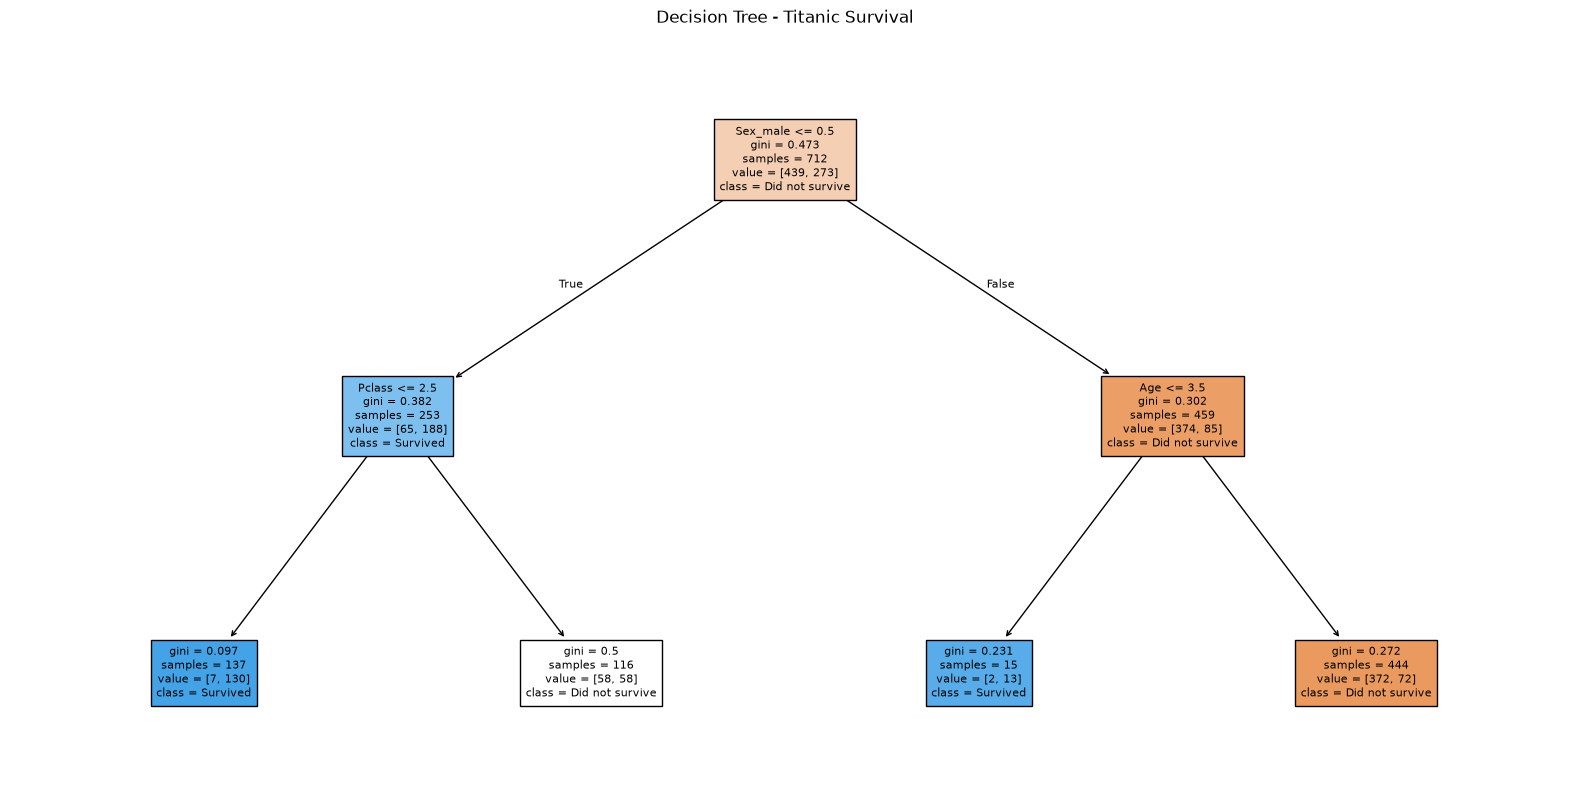

In [48]:
# Visualize the tree - you can literally read the questions it asks!
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Did not survive", "Survived"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree - Titanic Survival")
plt.show()


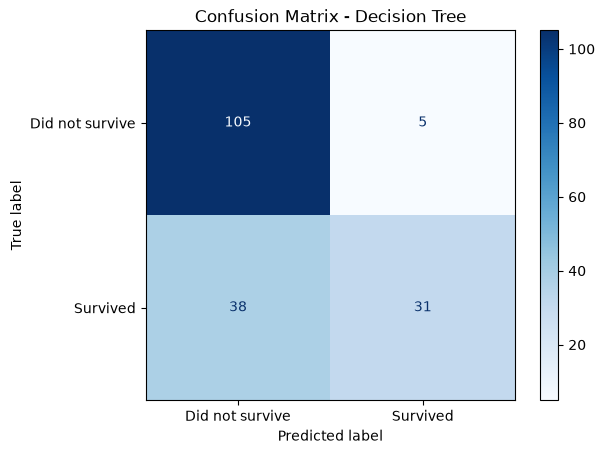

In [49]:
# Confusion matrix for the Decision Tree
cm_tree = confusion_matrix(y_test, tree_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


---
## PART 2 — Random Forest Classifier

`n_estimators=100` means "build 100 trees in the forest". Each tree sees a slightly different random slice of the data, and the forest combines their votes for the final answer.


In [50]:
forest_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.2%}")


Random Forest Accuracy: 79.89%


## Changing n_estimator to 10 or 300

In [51]:
forest_model = RandomForestClassifier(n_estimators=10, max_depth=4, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.2%}")


Random Forest Accuracy: 79.89%


In [52]:
forest_model = RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.2%}")


Random Forest Accuracy: 78.77%


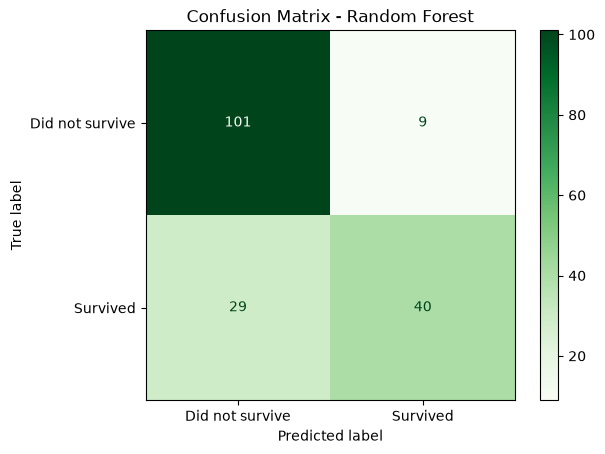

In [53]:
cm_forest = confusion_matrix(y_test, forest_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.show()


### Step 6: Which features mattered most?

Random Forest can tell us which columns were most useful for making predictions — this is called **feature importance**.


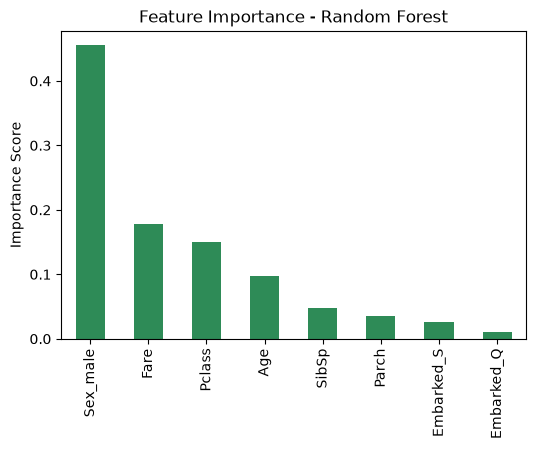

Sex_male      0.455050
Fare          0.177960
Pclass        0.150175
Age           0.097552
SibSp         0.047090
Parch         0.035664
Embarked_S    0.026422
Embarked_Q    0.010088
dtype: float64

In [54]:
importances = pd.Series(forest_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar", color="seagreen")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

importances


## Step 7: Compare Decision Tree vs Random Forest


In [55]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [tree_accuracy, forest_accuracy]
})
comparison


,Model,Accuracy
0,Decision Tree,0.759777
1,Random Forest,0.787709


## Step 8: Predict for a brand-new passenger

Let's make up a passenger: a 28-year-old female, travelling in 1st class, no siblings/spouses or parents/children aboard, fare of 100, boarded from Southampton ('S').

Note: because we one-hot encoded `Sex` and `Embarked`, we must build the row using the exact same columns as `X`.


In [56]:
new_passenger = pd.DataFrame([{
    "Pclass": 1,
    "Age": 28,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 100,
    "Sex_male": 0,      # 0 = female
    "Embarked_Q": 0,
    "Embarked_S": 1      # boarded from Southampton
}])

# Make sure column order matches training data
new_passenger = new_passenger[X.columns]

tree_result = tree_model.predict(new_passenger)[0]
forest_result = forest_model.predict(new_passenger)[0]

print("Decision Tree prediction:", "Survived" if tree_result == 1 else "Did not survive")
print("Random Forest prediction:", "Survived" if forest_result == 1 else "Did not survive")


Decision Tree prediction: Survived
Random Forest prediction: Survived


---
## Final Summary: Decision Tree vs Random Forest

| | Decision Tree | Random Forest |
|---|---|---|
| How it works | One flowchart of Yes/No questions | Many trees voting together |
| Accuracy | Good, but can overfit | Usually higher, more stable |
| Speed | Very fast | Slower (many trees) but still quick for small data |
| Interpretability | Easy to visualize and explain | Harder to visualize (100 trees!), but feature importance helps |
| Sklearn class | `DecisionTreeClassifier` | `RandomForestClassifier` |

**Try it yourself:**
1. Change `max_depth` to 2 or to `None` (unlimited) — how does accuracy change?
2. Change `n_estimators` in the Random Forest to 10 or 300 — does accuracy change much?
3. Try adding the `Name` column back in (hint: you'd need to extract the passenger's title like "Mr", "Mrs", "Miss" first — a common real-world feature engineering trick!)

### Dataset used in this lab
Titanic dataset CSV: `https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


## Answers

## Part 01

### By changing max_depth in decision tree to 2 accuracy is decreased from 78.77% to  75.98%

## Part 02

### By changing n_estimator in the random forest when we go to 10 then acurracy is same as previous 79.89% but when we change it to 300 then accuracy will be decreased to 78.77%

## Part:03

In [57]:
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [58]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df2 = pd.read_csv(url)

titanic_df2.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
titanic_df['Name'] = titanic_df2['Name']
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title,Name
0,0,3,22.0,1,0,7.2500,True,False,True,Mr,"Braund, Mr. Owen Harris"
1,1,1,38.0,1,0,71.2833,False,False,False,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,1,3,26.0,0,0,7.9250,False,False,True,Miss,"Heikkinen, Miss. Laina"
3,1,1,35.0,1,0,53.1000,False,False,True,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,0,3,35.0,0,0,8.0500,True,False,True,Mr,"Allen, Mr. William Henry"
